# 04 — Regression Plots, Matrix Heatmaps & Seaborn Objects API
**Preetham's Seaborn Mastery Series**

This notebook covers advanced statistical linear modeling, matrix visualizations (correlation heatmaps and hierarchical clustering), and the modern Seaborn Objects API (`seaborn.objects` / `so.Plot`).

### Notebook Contents:
1. **Linear Regression Modeling (`sns.regplot`, `sns.lmplot`)**
2. **Advanced Regression Variants (Polynomial, Logistic, Robust & LOWESS)**
3. **Residual Analysis (`sns.residplot`)**
4. **Correlation & Matrix Heatmaps (`sns.heatmap`)**
5. **Hierarchical Cluster Maps (`sns.clustermap`)**
6. **Modern Seaborn Objects API (`so.Plot`, `so.Dot`, `so.Line`, `so.Bar`, `so.KDE`, `so.PolyFit`)**
7. **Summary & Key Takeaways**


In [1]:
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load Datasets
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")
titanic = sns.load_dataset("titanic").dropna(subset=["age", "fare", "survived"])
anscombe = sns.load_dataset("anscombe")

print("Tips Sample:")
print(tips.head())


Tips Sample:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


## 1. Linear Regression Visualizations (`sns.regplot` & `sns.lmplot`)

- `regplot()`: Axes-level linear regression fitting with bootstrap confidence interval shading.
- `lmplot()`: Figure-level regression interface with multi-subplot categorical faceting (`col`, `row`).


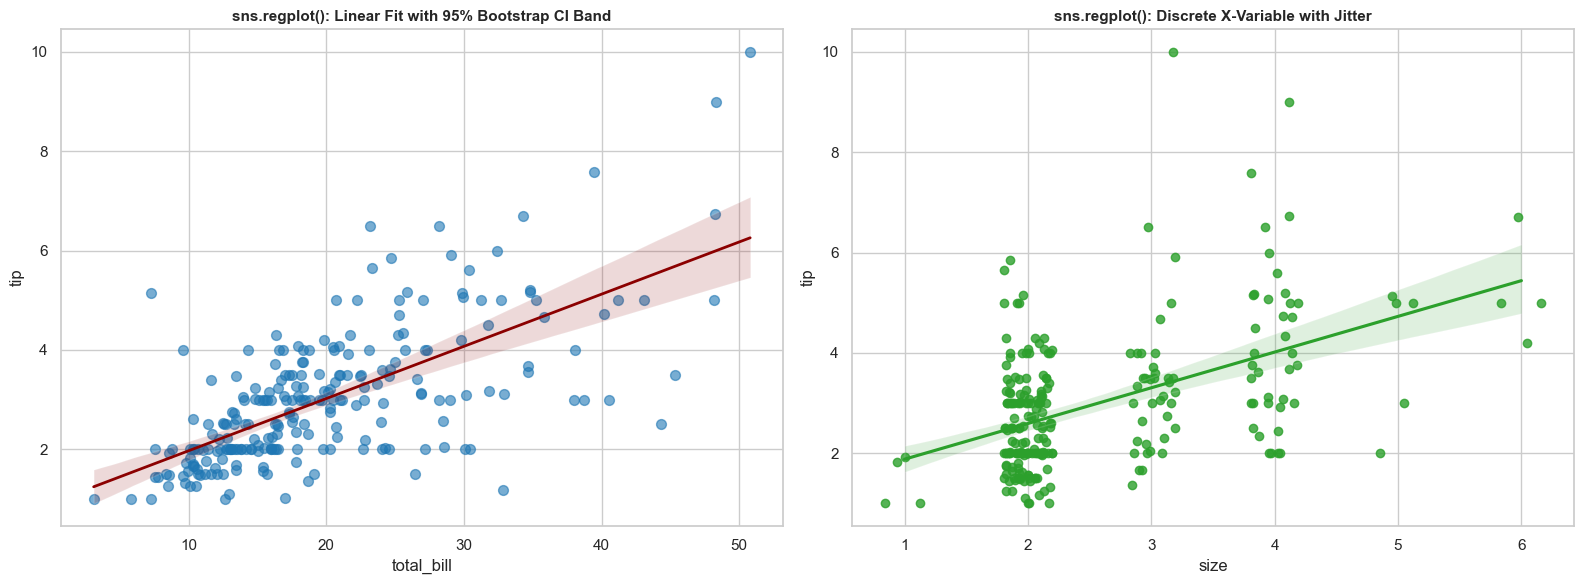

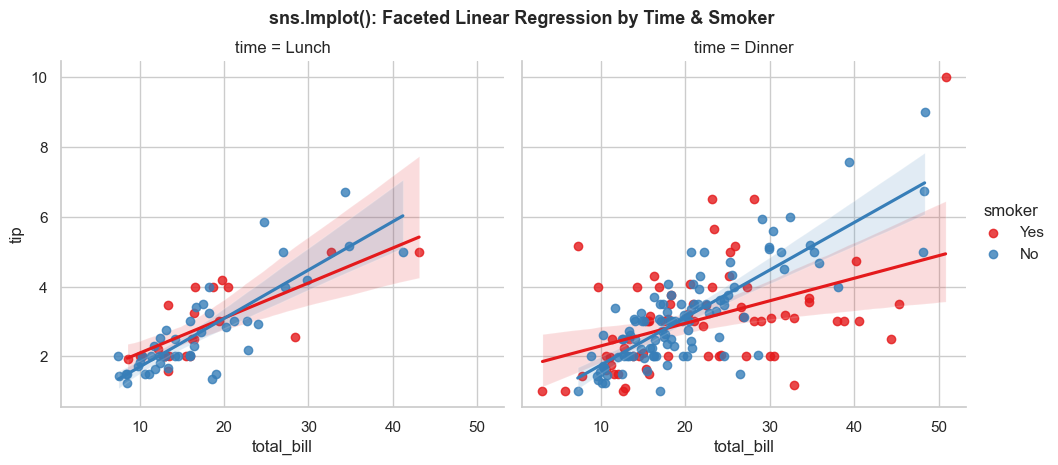

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regplot with confidence interval customization
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    ci=95,
    color="#1f77b4",
    scatter_kws={"alpha": 0.6, "s": 50},
    line_kws={"color": "darkred", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("sns.regplot(): Linear Fit with 95% Bootstrap CI Band", fontsize=11, fontweight="bold")

# Regplot with categorical discrete jittering
sns.regplot(
    data=tips,
    x="size",
    y="tip",
    x_jitter=0.2,
    color="#2ca02c",
    ax=axes[1]
)
axes[1].set_title("sns.regplot(): Discrete X-Variable with Jitter", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# Figure-level lmplot with column faceting by smoker
g = sns.lmplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    col="time",
    palette="Set1",
    height=4.5,
    aspect=1.1
)
g.fig.suptitle("sns.lmplot(): Faceted Linear Regression by Time & Smoker", y=1.03, fontsize=13, fontweight="bold")
plt.show()


## 2. Advanced Regression Models (Polynomial, Logistic, Robust & LOWESS)

Seaborn supports specialized fitting algorithms:
- `order=2` / `order=3`: Polynomial curve fitting.
- `robust=True`: Robust regression using Huber M-estimator to resist outlier skew.
- `logistic=True`: Logistic regression for binary outcome modeling ($Y \in \{0, 1\}$).
- `lowess=True`: Locally Weighted Scatterplot Smoothing (non-parametric curve).


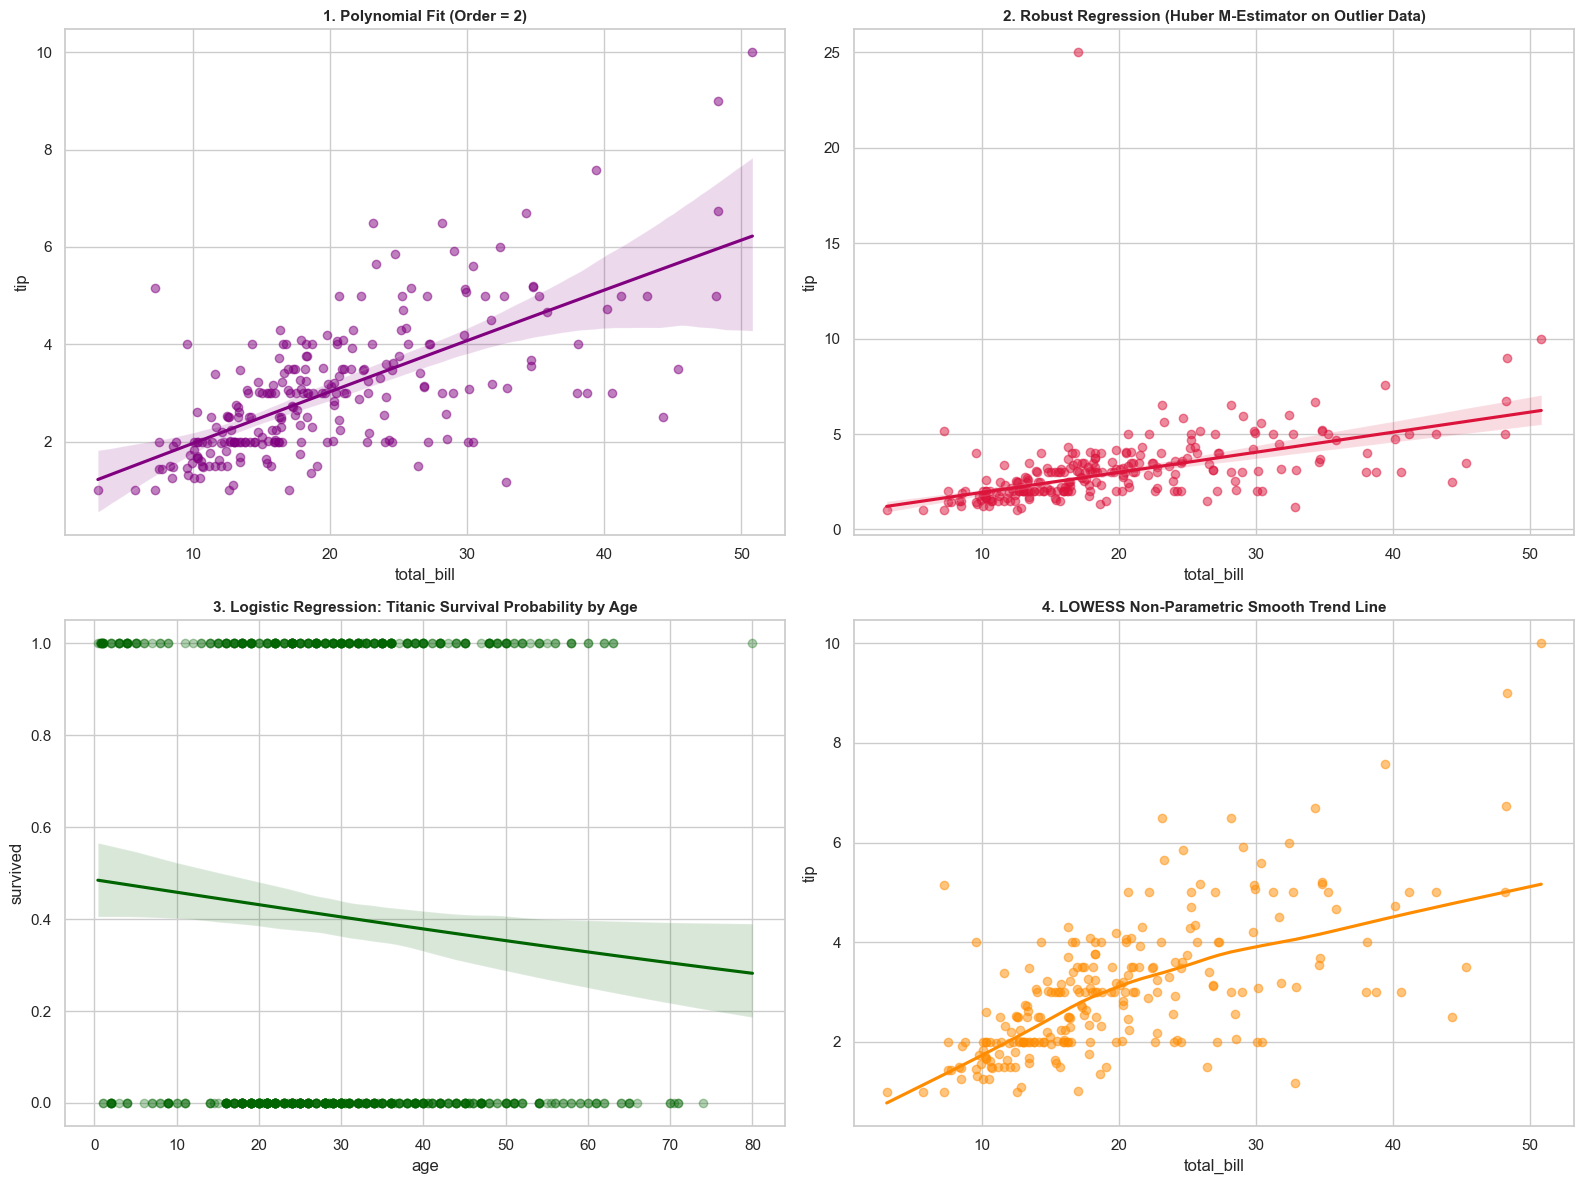

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Polynomial Fit (Order = 2)
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    order=2,
    color="purple",
    scatter_kws={"alpha": 0.5},
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Polynomial Fit (Order = 2)", fontsize=11, fontweight="bold")

# 2. Robust Regression (Outlier Resistant)
tips_outlier = tips.copy()
tips_outlier.loc[0, "tip"] = 25.0

sns.regplot(
    data=tips_outlier,
    x="total_bill",
    y="tip",
    robust=True,
    color="crimson",
    scatter_kws={"alpha": 0.5},
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Robust Regression (Huber M-Estimator on Outlier Data)", fontsize=11, fontweight="bold")

# 3. Logistic Regression (Survival Probability vs Age)
sns.regplot(
    data=titanic,
    x="age",
    y="survived",
    logistic=True,
    n_boot=100,
    color="darkgreen",
    scatter_kws={"alpha": 0.3},
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Logistic Regression: Titanic Survival Probability by Age", fontsize=11, fontweight="bold")

# 4. LOWESS Smoothing Curve
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    lowess=True,
    color="darkorange",
    scatter_kws={"alpha": 0.5},
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. LOWESS Non-Parametric Smooth Trend Line", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 3. Residual Analysis (`sns.residplot`)

A residual plot checks model assumptions by plotting predicted residuals against independent variables. Ideal residuals are randomly scattered around $y = 0$ with homoscedastic variance.


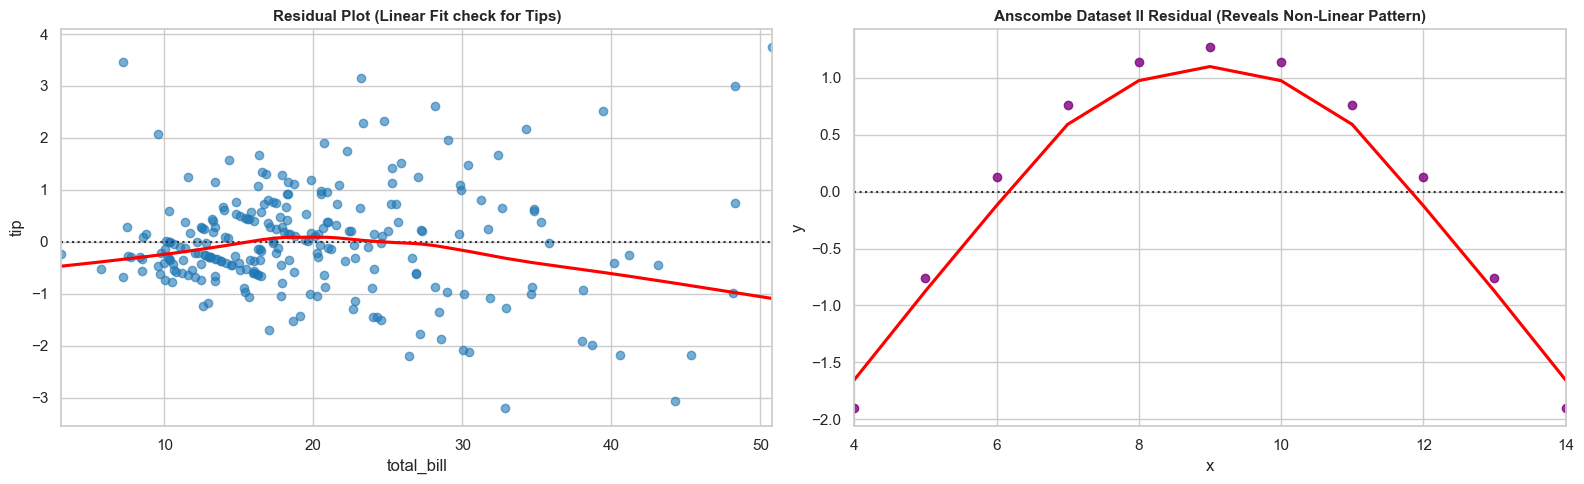

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear model residuals
sns.residplot(
    data=tips,
    x="total_bill",
    y="tip",
    lowess=True,
    color="#1f77b4",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("Residual Plot (Linear Fit check for Tips)", fontsize=11, fontweight="bold")

# Anscombe's Quartet Dataset II Residual check
anscombe_2 = anscombe[anscombe["dataset"] == "II"]
sns.residplot(
    data=anscombe_2,
    x="x",
    y="y",
    lowess=True,
    color="purple",
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title("Anscombe Dataset II Residual (Reveals Non-Linear Pattern)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 4. Matrix Heatmaps (`sns.heatmap`)

`heatmap()` converts 2D numerical data or correlation matrices into color-coded grid visualizations.
Key customization options:
- `annot=True`, `fmt=".2f"`: Cell text numbers.
- `mask`: Triangular mask to remove duplicate upper/lower symmetric entries.
- `cmap`: Diverging or sequential colormaps (`vlag`, `coolwarm`, `mako`, `viridis`).


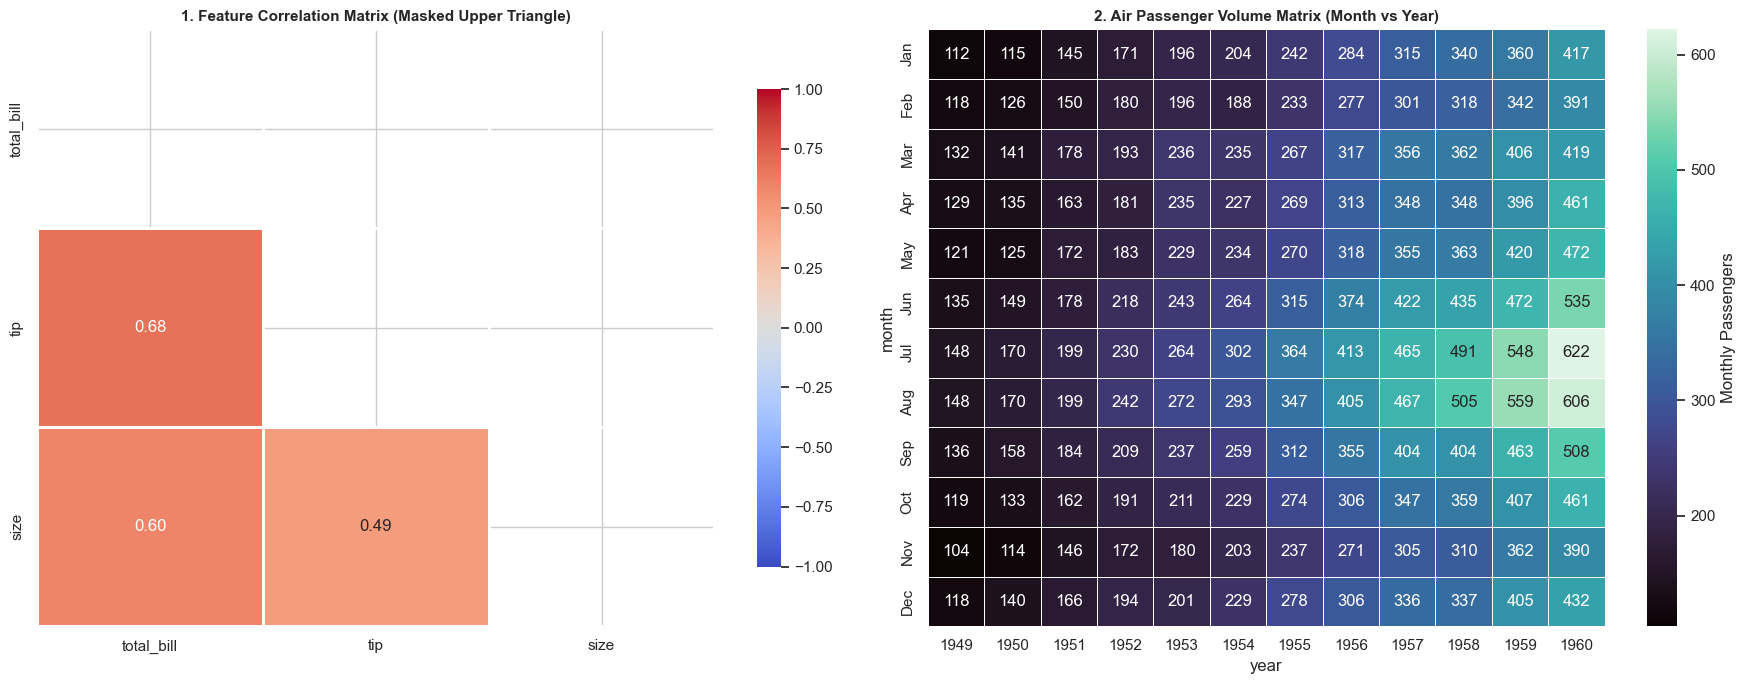

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Correlation Matrix Heatmap with Upper Triangle Mask
numeric_tips = tips.select_dtypes(include="number")
corr_matrix = numeric_tips.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=mask,
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title("1. Feature Correlation Matrix (Masked Upper Triangle)", fontsize=11, fontweight="bold")

# 2. Pivot Matrix Heatmap (Monthly Passenger Trends)
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

sns.heatmap(
    flights_pivot,
    annot=True,
    fmt="d",
    cmap="mako",
    linewidths=0.5,
    cbar_kws={"label": "Monthly Passengers"},
    ax=axes[1]
)
axes[1].set_title("2. Air Passenger Volume Matrix (Month vs Year)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Hierarchical Cluster Maps (`sns.clustermap`)

`clustermap()` performs agglomerative hierarchical clustering on matrix rows and columns, reorganizing data to group similar observation patterns together with dendrograms.


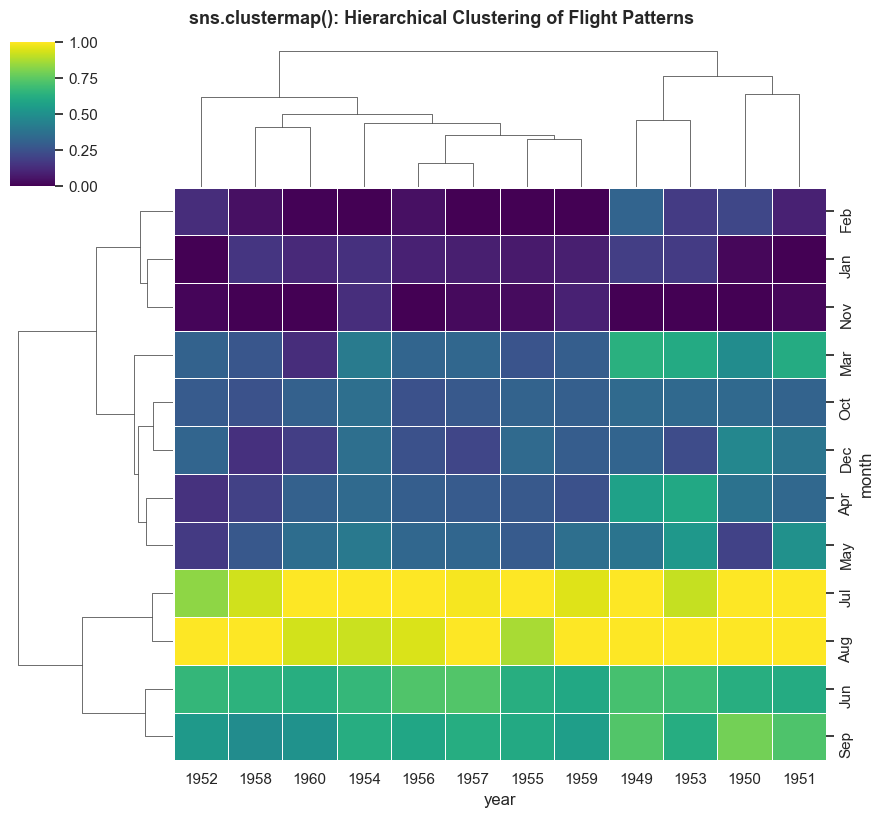

In [6]:
# Clustermap on Normalized Flights Passenger Data
g = sns.clustermap(
    flights_pivot,
    cmap="viridis",
    standard_scale=1,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.5,
    figsize=(9, 8)
)
g.fig.suptitle("sns.clustermap(): Hierarchical Clustering of Flight Patterns", y=1.02, fontsize=13, fontweight="bold")
plt.show()


## 6. Modern Seaborn Objects API (`seaborn.objects` / `so.Plot`)

Introduced in Seaborn v0.12+, `seaborn.objects` is a declarative, composable, grammar-of-graphics interface inspired by ggplot2.
Key building blocks:
- `so.Plot(data, x, y, color, marker)`
- Marks: `so.Dot()`, `so.Line()`, `so.Bar()`, `so.Hist()`, `so.Area()`
- Stat Transforms: `so.Agg()`, `so.Hist()`, `so.KDE()`, `so.PolyFit()`
- Moves: `so.Dodge()`, `so.Stack()`
- Layout & Faceting: `.facet()`, `.layout()`, `.label()`, `.scale()`


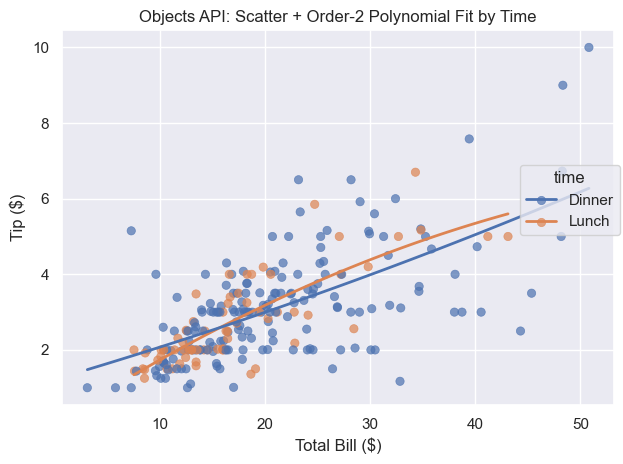

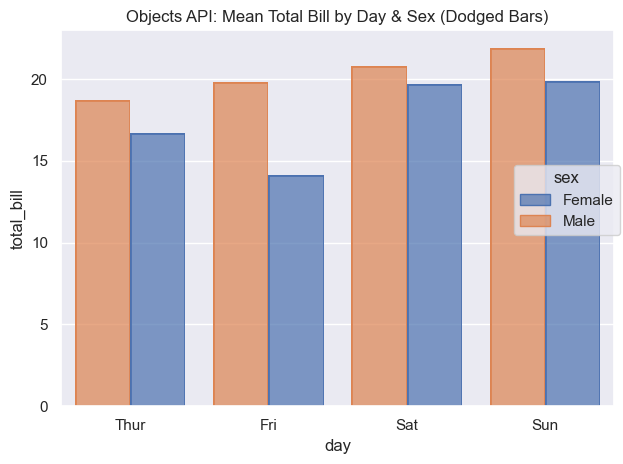

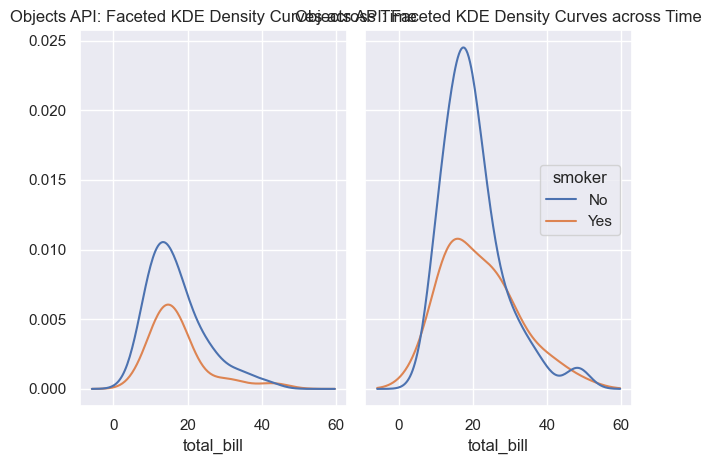

In [7]:
# 1. Objects API Scatter + PolyFit Polynomial Regression
p1 = (
    so.Plot(tips, x="total_bill", y="tip", color="time")
    .add(so.Dot(alpha=0.7, pointsize=6))
    .add(so.Line(linewidth=2), so.PolyFit(order=2))
    .label(title="Objects API: Scatter + Order-2 Polynomial Fit by Time", x="Total Bill ($)", y="Tip ($)")
)
p1.show()

# 2. Objects API Aggregated Bar Chart with Dodged Categories
p2 = (
    so.Plot(tips, x="day", y="total_bill", color="sex")
    .add(so.Bar(), so.Agg("mean"), so.Dodge())
    .label(title="Objects API: Mean Total Bill by Day & Sex (Dodged Bars)")
)
p2.show()

# 3. Objects API Faceted KDE Density Curves
p3 = (
    so.Plot(tips, x="total_bill", color="smoker")
    .facet("time")
    .add(so.Line(), so.KDE())
    .label(title="Objects API: Faceted KDE Density Curves across Time")
)
p3.show()


## 7. Summary & Key Takeaways

- Use `regplot()` or `lmplot()` for rapid parametric linear regression visualization.
- Use `order=2`, `robust=True`, or `logistic=True` when dealing with non-linear trends, heavy outliers, or binary targets.
- Validate regression linearity assumptions using `residplot()`.
- Use `heatmap()` for correlation matrices and pivot grids; use `clustermap()` to uncover hidden structural clusters.
- Embrace `seaborn.objects` (`so.Plot`) for modern, modular, declarative plot composition.
